<Axes: xlabel='median_house_value', ylabel='Count'>

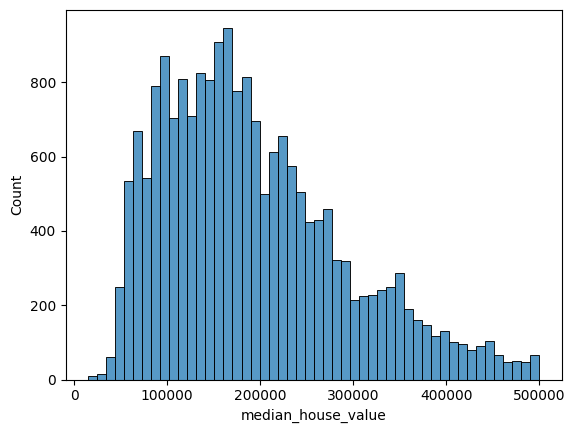

In [84]:
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("housing_modified.csv")

# for further analysis I will delete extreme values of target variable as it was already detected:
df = df.query("median_house_value < median_house_value.quantile(0.98)")

# now it looks better:
sns.histplot(df['median_house_value'])




<Axes: xlabel='housing_median_age', ylabel='Count'>

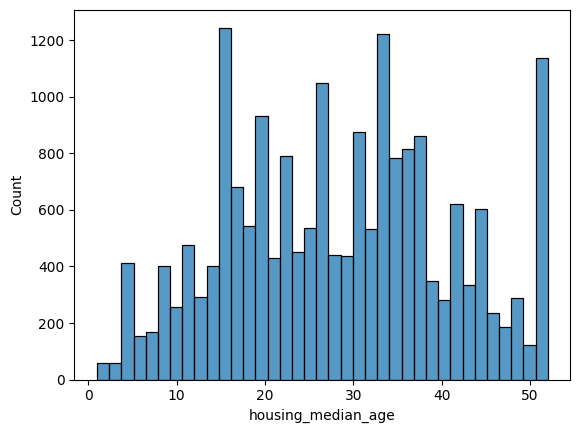

In [85]:
# housing_median_age large spike at the right edge gone, now distrubution looks like this:
sns.histplot(df['housing_median_age'])

In [86]:
# I will drop "households", "total_bedrooms" because of multicollinearity and to have less variables to inspect.
df.drop(columns=["households", "total_bedrooms"], inplace=True)

In [87]:
# trimming total_rooms and population variables:
df = df.query("total_rooms < total_rooms.quantile(0.97)")
df = df.query("population < population.quantile(0.97)")



<Axes: xlabel='total_rooms', ylabel='Count'>

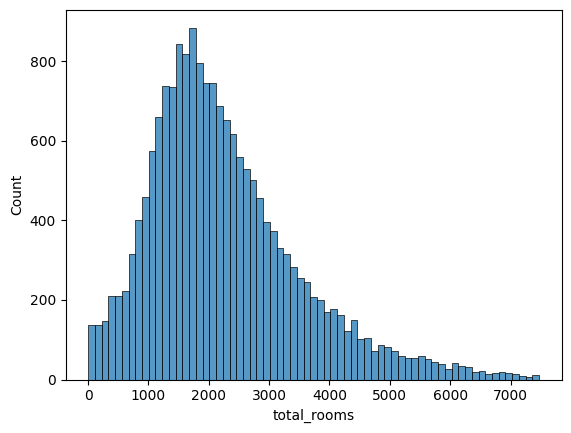

In [88]:
# still there is a tail but not that long as it was 
sns.histplot(df['total_rooms'])

<Axes: xlabel='population', ylabel='Count'>

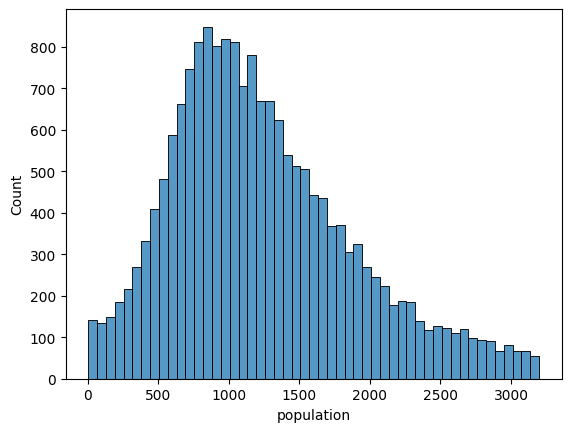

In [89]:
# the same here:
sns.histplot(df['population'])

In [90]:
df.to_csv("housing_trimmed_variables.csv", index=False)

In [91]:
df.columns

Index(['housing_median_age', 'total_rooms', 'population', 'median_income',
       'median_house_value', 'distance_to_nearest_city',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY'],
      dtype='object')

In [92]:
print(len(inliers))
print(len(noise))

16624
1698


In [93]:
variable = "median_income"

# Calculate the median
median = df[variable].median()

# Calculate MAD
mad = np.median(np.abs(df[variable] - median))

# Define a threshold for noise detection
# adjust the numeric modifier for aggressiveness 
# e.g. try 2.5 or 4.5 etc.
# if the value is too high, you will find no noise (decrease in that case)
threshold = 3.5 * mad

# Detect noise
noise = df[np.abs(df[variable] - median) > threshold]

inliers = df.drop(noise.index)

print("Detected noise using MAD:")
noise

Detected noise using MAD:


,housing_median_age,total_rooms,population,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
0,41.0,880.0,322.0,8.3252,452600.0,20.33,0,0,0,1
1,21.0,7099.0,2401.0,8.3014,358500.0,19.91,0,0,0,1
2,52.0,1467.0,496.0,7.2574,352100.0,17.84,0,0,0,1
124,52.0,2612.0,901.0,7.2354,391100.0,17.84,0,0,0,1
126,50.0,2935.0,1031.0,7.5000,295200.0,18.95,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
20233,17.0,1986.0,761.0,7.2137,401900.0,55.32,1,0,0,0
20237,13.0,1841.0,833.0,7.7785,404700.0,54.03,1,0,0,0
20280,5.0,6123.0,2440.0,7.9013,393000.0,47.93,1,0,0,0
20296,27.0,534.0,243.0,8.2787,330000.0,55.88,1,0,0,0


In [94]:
print(len(inliers))
print(len(noise))
print(len(df))

17711
611
18322


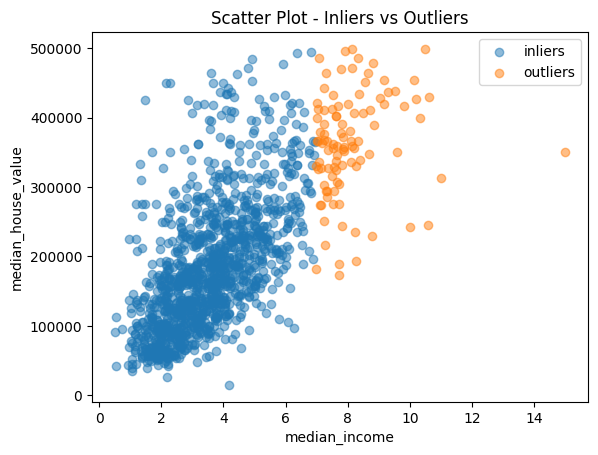

In [95]:
import matplotlib.pyplot as plt

variable = "median_income"
target = "median_house_value"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(1200)
outliers_sample = noise.sample(100)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

In [96]:
df.columns

Index(['housing_median_age', 'total_rooms', 'population', 'median_income',
       'median_house_value', 'distance_to_nearest_city',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY'],
      dtype='object')

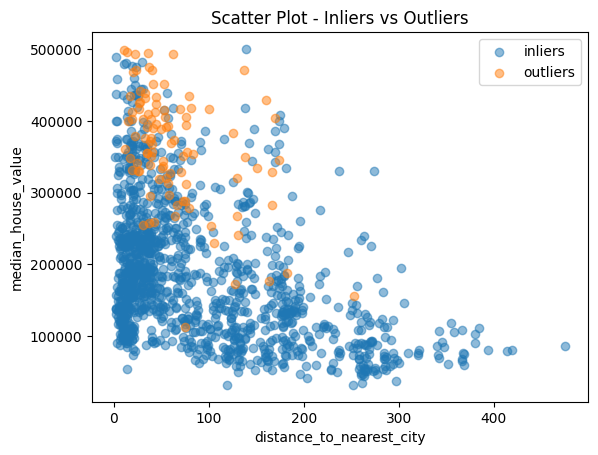

In [97]:
import matplotlib.pyplot as plt

variable = "distance_to_nearest_city"
target = "median_house_value"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(1200)
outliers_sample = noise.sample(100)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

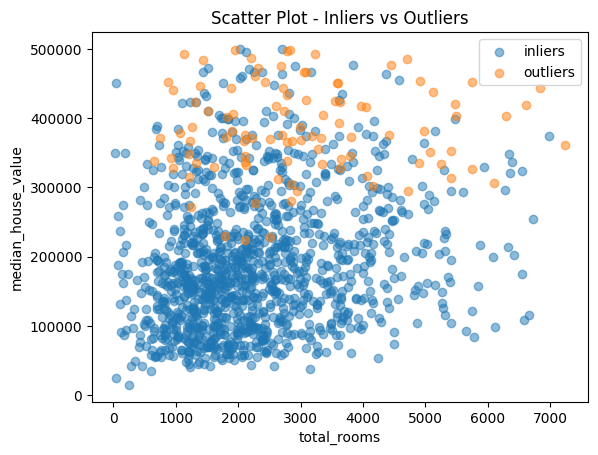

In [98]:
import matplotlib.pyplot as plt

variable = "total_rooms"
target = "median_house_value"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(1200)
outliers_sample = noise.sample(100)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()